In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from scipy.optimize import fsolve
import plotly.graph_objects as go
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey

## Data Loading

In [34]:
df = pd.read_csv(r'C:\\Users\\indra\\Desktop\\GitHub\\AI Appliction\\emissions_top30.csv')

In [35]:
df.head()

,Country_x,ISO3,Year,GHG_Emissions,GDP_USD,Country_y,Unit,Population,GDPperCapita,GHGperCapita,Emission_Intensity,ln_GDPpc,ln_Emissions_pc,income_group
0,Algeria,DZA,1999,145380.420073,4.864067e+10,Algeria,Persons,30474354.0,1596.118222,0.004771,0.000003,7.375330,-5.345287,Lower-Middle
1,Algeria,DZA,2000,153676.186499,5.479040e+10,Algeria,Persons,30903893.0,1772.928691,0.004973,0.000003,7.480388,-5.303790,Lower-Middle
2,Algeria,DZA,2001,142934.116590,5.941340e+10,Algeria,Persons,31331221.0,1896.300209,0.004562,0.000002,7.547660,-5.389987,Lower-Middle
3,Algeria,DZA,2002,142318.802781,6.151610e+10,Algeria,Persons,31750835.0,1937.464114,0.004482,0.000002,7.569135,-5.407605,Lower-Middle
4,Algeria,DZA,2003,155936.346849,7.348226e+10,Algeria,Persons,32175818.0,2283.772993,0.004846,0.000002,7.733584,-5.329523,Lower-Middle


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country_x           780 non-null    str    
 1   ISO3                780 non-null    str    
 2   Year                780 non-null    int64  
 3   GHG_Emissions       780 non-null    float64
 4   GDP_USD             780 non-null    float64
 5   Country_y           780 non-null    str    
 6   Unit                780 non-null    str    
 7   Population          780 non-null    float64
 8   GDPperCapita        780 non-null    float64
 9   GHGperCapita        780 non-null    float64
 10  Emission_Intensity  780 non-null    float64
 11  ln_GDPpc            780 non-null    float64
 12  ln_Emissions_pc     780 non-null    float64
 13  income_group        780 non-null    str    
dtypes: float64(8), int64(1), str(5)
memory usage: 85.4 KB


## Feature engineering for EKC
#### GDP per capita was mean-centered prior to polynomial expansion to mitigate multicollinearity among the linear, quadratic, and cubic terms.
##### ß1=ln_gdp_centered
##### ß2=ln_gdp_centered_sq
##### ß3=ln_gdp_centered_cub

In [37]:
df['ln_gdp_centered'] = df['ln_GDPpc'] - df['ln_GDPpc'].mean()
df['ln_gdp_centered_sq'] = df['ln_gdp_centered'] ** 2
df['ln_gdp_centered_cub'] = df['ln_gdp_centered'] ** 3

## Pooled OLS (Ordinary Least Squares) baseline regression analysis
#### ln(GHG/capita) = α + β₁x + β₂x² + β₃x³ + ε, where x is the mean-centred natural log of GDP per capita. 

In [38]:

X = df[['ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub']]
X = sm.add_constant(X)
y = df['ln_Emissions_pc']

In [39]:
model_pooled = sm.OLS(y, X).fit(cov_type='HC3')  # robust standard errors
print(" Pooled OLS(Ordinary Least Squares) (Cubic EKC)")
print(model_pooled.summary())
# Interpret: If β₂ < 0, the inverted-U EKC holds
# If β₃ > 0, it's an N-shaped curve (emissions may rise again)

 Pooled OLS(Ordinary Least Squares) (Cubic EKC)
                            OLS Regression Results                            
Dep. Variable:        ln_Emissions_pc   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     287.2
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          2.32e-125
Time:                        13:14:19   Log-Likelihood:                -581.71
No. Observations:                 780   AIC:                             1171.
Df Residuals:                     776   BIC:                             1190.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

#### Since, ß1>0 (0.55) (emissions initially rise with income)
####       ß2<0 (-0.06) (the curve eventually bends downward), while
####       ß3<0 (-0.39) (it tells that the decline accelerate rather than going up and making a N shape curve) 

## Fixed Effects Panel Regression Analysis
#### Where, Country and time fixed effects

In [40]:

panel_df = df.set_index(['ISO3', 'Year']) 

fe_model = PanelOLS(
    panel_df['ln_Emissions_pc'],
    panel_df[['ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub']], 
    entity_effects=True,    # country fixed effects
    time_effects=True,      # year fixed effects
    ).fit(cov_type='clustered', cluster_entity=True)

print("\\n=== Fixed Effects Panel Model ===")
print(fe_model.summary)

\n=== Fixed Effects Panel Model ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        ln_Emissions_pc   R-squared:                        0.4596
Estimator:                   PanelOLS   R-squared (Between):              0.0490
No. Observations:                 780   R-squared (Within):               0.0682
Date:                Thu, Mar 26 2026   R-squared (Overall):              0.0490
Time:                        13:14:19   Log-likelihood                    631.57
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      204.72
Entities:                          30   P-value                           0.0000
Avg Obs:                       26.000   Distribution:                   F(3,722)
Min Obs:                       26.000                                           
Max Obs:                       26.000   F-statistic (robust):            

## Find the EKC turning point

In [41]:
b1 = model_pooled.params['ln_gdp_centered']
b2 = model_pooled.params['ln_gdp_centered_sq']
b3 = model_pooled.params['ln_gdp_centered_cub']

mean_ln_gdp = df['ln_GDPpc'].mean()

# Solve: 3*b3*x² + 2*b2*x + b1 = 0
a = 3 * b3
b = 2 * b2
c = b1

discriminant = b**2 - 4*a*c

if discriminant >= 0:
    x1 = (-b + np.sqrt(discriminant)) / (2 * a)
    x2 = (-b - np.sqrt(discriminant)) / (2 * a)
    
    # Pick the root that is a maximum (second derivative < 0)
    # Second derivative: 2*b2 + 6*b3*x
    for x in [x1, x2]:
        second_deriv = 2*b2 + 6*b3*x
        if second_deriv < 0:
            turning_point_gdp = np.exp(x + mean_ln_gdp)
            turning_point_centered = x
            print(f"Turning point (cubic): ${turning_point_gdp:,.0f}")
            print(f"  Centered value: {turning_point_centered:.4f}")
            print(f"  Second derivative: {second_deriv:.4f} (negative = confirmed maximum)")
            break
else:
    print("No real turning point exists (discriminant < 0)")

Turning point (cubic): $46,398
  Centered value: 1.6811
  Second derivative: -0.5216 (negative = confirmed maximum)


The turning point of $46,398 means that at this GDP/capita, the countries show a decline in emissions.

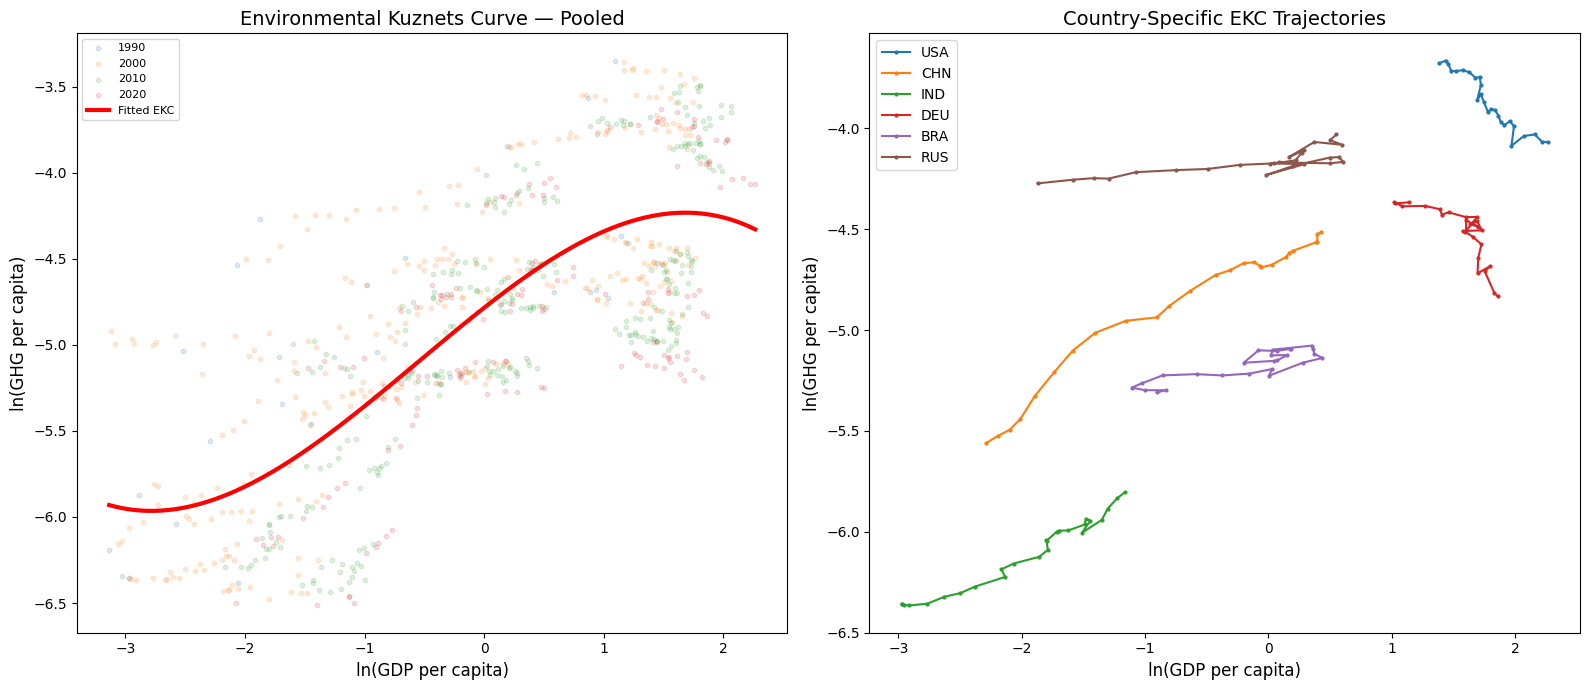

In [42]:
# ============================================================
# STEP 5: Visualize EKC
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) Scatter with fitted curve
ax = axes[0]
gdp_range = np.linspace(df['ln_gdp_centered'].min(), df['ln_gdp_centered'].max(), 200)
predicted = model_pooled.predict(sm.add_constant(
    pd.DataFrame({
        'ln_gdp_centered': gdp_range,
        'ln_gdp_centered_sq': gdp_range**2,
        'ln_gdp_centered_cub': gdp_range**3
    })
))

# Color by decade
df['Decade'] = (df['Year'] // 10) * 10
for decade, group in df.groupby('Decade'):
    ax.scatter(group['ln_gdp_centered'], group['ln_Emissions_pc'],
               alpha=0.15, s=10, label=str(decade))

ax.plot(gdp_range, predicted, 'r-', linewidth=3, label='Fitted EKC')
ax.set_xlabel('ln(GDP per capita)', fontsize=12)
ax.set_ylabel('ln(GHG per capita)', fontsize=12)
ax.set_title('Environmental Kuznets Curve — Pooled', fontsize=14)
ax.legend(fontsize=8)

# (b) Country-specific EKC trajectories
ax = axes[1]
highlight_countries = ['USA', 'CHN', 'IND', 'DEU', 'BRA', 'RUS']
for iso in highlight_countries:
    country_data = df[df['ISO3'] == iso].sort_values('Year')
    ax.plot(country_data['ln_gdp_centered'], country_data['ln_Emissions_pc'],
            '-o', markersize=2, label=iso, linewidth=1.5)

ax.set_xlabel('ln(GDP per capita)', fontsize=12)
ax.set_ylabel('ln(GHG per capita)', fontsize=12)
ax.set_title('Country-Specific EKC Trajectories', fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig('ekc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Left Graph: The Pooled EKC Curve
 Each dot is one country in one year color-coded by decade. The x-axis is centered ln(GDP per capita), so 0 represents the sample average income, negative values are poorer countries, and positive values are richer ones.
The red curve shows the regression. Starting from the left (poorest countries), emissions rise steeply as income increases. Around x = 0 to 1 (middle-to-upper income), the curve flattens and reaches its peak. Past x = 1.5 or so, it bends sharply downwards, pulling emissions down at high incomes.
The scatter points don't tightly hug the red line, especially at the right side. Several high-income observations sit well above the curve, while the curve predicts they should be lower. This visual spread reflects the R-squared of 0.57 — the model captures the general shape but can't explain everything. The high-income outliers above the curve are likely oil-rich Gulf states (UAE, Saudi Arabia) whose emissions stay elevated despite high GDP.

Right Graph: Country Trajectories
It traces each country's actual path through time. Each line starts at the country's 1999 position and ends at 2024, with the trajectory showing how both GDP and emissions evolved simultaneously.
USA (blue, top right) — Starts at the highest income and highest emissions. The trajectory moves right (getting richer) while curving downward (reducing emissions).
China (orange, center) —It starts from lower-left to upper-right— rapid GDP growth accompanied by rapid emissions growth. The curve starts to flatten toward the end, suggesting China may be approaching its turning point but hasn't clearly crossed it yet.
India (green, bottom left) — Steadily moving up and to the right. Both income and emissions are rising together. India is firmly in the pre-turning-point phase, still early on the upward slope.
Germany (red, right side) — High income, with a clear leftward and downward drift in recent years. Germany is past the peak and actively reducing emissions, though with some zigzagging that likely reflects energy policy shifts.
Brazil (purple, center) — The most erratic trajectory, bouncing horizontally without a clear direction. Emissions fluctuate without a strong link to GDP changes. This suggests Brazil's emissions are driven more by land-use changes (deforestation) than by industrial growth — something a GDP-based EKC model can't capture well.
Russia (brown, upper center) — Relatively flat. High emissions, moderate income, not much movement in either direction. Russia's carbon-intensive economy hasn't shifted significantly despite some GDP growth.

## Visualize EKC

In [43]:

# --- Fitted curve ---
gdp_range = np.linspace(df['ln_gdp_centered'].min() - 0.3,
                         df['ln_gdp_centered'].max() + 0.3, 300)
predicted = model_pooled.predict(sm.add_constant(
    pd.DataFrame({
        'ln_gdp_centered': gdp_range,
        'ln_gdp_centered_sq': gdp_range**2,
        'ln_gdp_centered_cub': gdp_range**3
    })
))

peak_y = (model_pooled.params['const']
          + b1 * turning_point_centered
          + b2 * turning_point_centered**2
          + b3 * turning_point_centered**3)

# --- Decade column ---
df['Decade'] = (df['Year'] // 10) * 10

decade_colors = {1990: '#3B82F6', 2000: '#F59E0B', 2010: '#10B981', 2020: '#EF4444'}


# ============================================================
# CHART 1: Pooled EKC — Interactive Scatter
# ============================================================
fig1 = go.Figure()

for decade in sorted(df['Decade'].unique()):
    group = df[df['Decade'] == decade]
    fig1.add_trace(go.Scatter(
        x=group['ln_gdp_centered'],
        y=group['ln_Emissions_pc'],
        mode='markers',
        name=f'{decade}s',
        marker=dict(size=7, color=decade_colors.get(decade, '#999'),
                    opacity=0.5, line=dict(width=0.5, color='white')),
       hovertemplate=(
            '<b>%{customdata[0]}</b> (%{customdata[1]})<br>'
            'Year: %{customdata[2]}<br>'    
            'GDP/capita: $%{customdata[3]:,.0f}<br>'
            'GHG/capita: %{customdata[4]:.4f} kt<br>'
            '<extra></extra>'
        ),
        customdata=np.column_stack([
            group['Country_x'].values,
            group['ISO3'].values,
            group['Year'].values,
            group['GDPperCapita'].values,
            group['GHGperCapita'].values
        ])
    ))

# Fitted curve
fig1.add_trace(go.Scatter(
    x=gdp_range, y=predicted,
    mode='lines', name='Fitted EKC (cubic)',
    line=dict(color='#DC2626', width=4),
    hovertemplate='Fitted ln(GHG/capita): %{y:.3f}<extra>Fitted EKC</extra>'
))

# Turning point dashed line
fig1.add_trace(go.Scatter(
    x=[turning_point_centered, turning_point_centered],
    y=[df['ln_Emissions_pc'].min() - 0.2, peak_y],
    mode='lines', name=f'Turning point (${turning_point_gdp:,.0f})',
    line=dict(color='#DC2626', width=2, dash='dash')
))

# Turning point annotation
fig1.add_annotation(
    x=turning_point_centered, y=peak_y + 0.15,
    text=f'<b>Turning Point</b><br>${turning_point_gdp:,.0f}/capita',
    showarrow=True, arrowhead=2, arrowwidth=2, arrowcolor='#DC2626',
    font=dict(size=12, color='#DC2626'),
    bgcolor='white', bordercolor='#DC2626', borderwidth=1, borderpad=6,
    ax=50, ay=-40
)
fig1.update_layout(
    title=dict(text='Environmental Kuznets Curve — Pooled OLS (Cubic)',
               font=dict(size=20), x=0.5),
    xaxis=dict(title='ln(GDP per capita) — centered', gridcolor='#F3F4F6',
               zeroline=True, zerolinecolor='#D1D5DB'),
    yaxis=dict(title='ln(GHG emissions per capita)', gridcolor='#F3F4F6'),
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
    hovermode='closest', width=950, height=650
)

fig1.show()

## Country-Specific Trajectories

In [44]:
fig2 = go.Figure()

highlight_countries = ['USA', 'CHN', 'IND', 'DEU', 'BRA', 'RUS']
country_colors = {
    'USA': '#3B82F6', 'CHN': '#F59E0B', 'IND': '#10B981',
    'DEU': '#EF4444', 'BRA': '#8B5CF6', 'RUS': '#78716C'
}

for iso in highlight_countries:
    cdata = df[df['ISO3'] == iso].sort_values('Year').reset_index(drop=True)
    if len(cdata) == 0:
        continue
    color = country_colors[iso]
    name = cdata['Country_x'].iloc[0]

    fig2.add_trace(go.Scatter(
        x=cdata['ln_gdp_centered'],
        y=cdata['ln_Emissions_pc'],
        mode='markers+lines',
        name=name,
        line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(width=0.5, color='white')),
        hovertemplate=(
            f'<b>{name}</b> ({iso})<br>'
            'Year: %{customdata[0]}<br>'
            'GDP/capita: $%{customdata[1]:,.0f}<br>'
            'GHG/capita: %{customdata[2]:.4f} kt'
            '<extra></extra>'
        ),
        customdata=np.column_stack([
            cdata['Year'].values,
            cdata['GDPperCapita'].values,
            cdata['GHGperCapita'].values
        ])
    ))

    # Start and end labels
    first, last = cdata.iloc[0], cdata.iloc[-1]
    fig2.add_annotation(
        x=first['ln_gdp_centered'], y=first['ln_Emissions_pc'],
        text=str(first['Year']), showarrow=False,
        font=dict(size=8, color=color), xshift=-15, yshift=-10
    )
    fig2.add_annotation(
        x=last['ln_gdp_centered'], y=last['ln_Emissions_pc'],
        text=f'<b>{iso}</b> ({last["Year"]})',
        showarrow=True, arrowhead=0, arrowwidth=1, arrowcolor=color,
        font=dict(size=10, color=color), ax=25, ay=-15
    )

# Turning point line
fig2.add_trace(go.Scatter(
    x=[turning_point_centered, turning_point_centered],
    y=[df['ln_Emissions_pc'].min() - 0.3, df['ln_Emissions_pc'].max() + 0.1],
    mode='lines', name=f'Turning point (${turning_point_gdp:,.0f})',
    line=dict(color='#DC2626', width=1.5, dash='dot')
))

fig2.update_layout(
    title=dict(text='Country-Specific EKC Trajectories (1999–2024)',
               font=dict(size=20), x=0.5),
    xaxis=dict(title='ln(GDP per capita) — centered', gridcolor='#F3F4F6',
               zeroline=True, zerolinecolor='#D1D5DB'),
    yaxis=dict(title='ln(GHG emissions per capita)', gridcolor='#F3F4F6'),
    plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(yanchor='top', y=0.98, xanchor='left', x=0.01,
                bgcolor='rgba(255,255,255,0.9)', bordercolor='#E5E7EB', borderwidth=1),
    hovermode='closest', width=950, height=650
)

fig2.show()

In [45]:
# ============================================================
# STEP 6: Country classification by EKC stage
# ============================================================
if b2 < 0:
    latest = df[df['Year'] == df['Year'].max()].copy()
    latest['EKC_stage'] = np.where(
        latest['ln_gdp_centered'] < turning_point_centered,
        'Pre-turning (rising emissions)',
        'Post-turning (declining emissions)'
    )
    print("\\n=== EKC Stage Classification ===")
    print(latest.groupby('EKC_stage')['ISO3'].apply(list))

\n=== EKC Stage Classification ===
EKC_stage
Post-turning (declining emissions)                       [AUS, CAN, DEU, ARE, GBR, USA]
Pre-turning (rising emissions)        [DZA, ARG, BRA, CHN, FRA, IND, IDN, IRQ, ITA, ...
Name: ISO3, dtype: object


## ROBUSTNESS CHECKS

In [46]:
# 1. Compare quadratic vs cubic specification
X_quad = sm.add_constant(df[['ln_gdp_centered', 'ln_gdp_centered_sq']])
model_quad = sm.OLS(y, X_quad).fit()

X_cubic = sm.add_constant(df[['ln_gdp_centered', 'ln_gdp_centered_sq', 'ln_gdp_centered_cub']])
model_cubic = sm.OLS(y, X_cubic).fit()

print(f"Quadratic AIC: {model_quad.aic:.1f} | Cubic AIC: {model_cubic.aic:.1f}")
print(f"Better model: {'Cubic (extended inverted-U)' if model_cubic.aic < model_quad.aic else 'Quadratic (inverted-U)'}")


# 3. Heteroscedasticity and serial correlation tests

bp_stat, bp_p, _, _ = het_breuschpagan(model_pooled.resid, X)
print(f"\\nBreusch-Pagan test: stat={bp_stat:.2f}, p={bp_p:.4f}")

Quadratic AIC: 1192.6 | Cubic AIC: 1171.4
Better model: Cubic (extended inverted-U)
\nBreusch-Pagan test: stat=19.61, p=0.0002


In [47]:

for period_name, mask in [('1999-2011', df['Year'].between(1999, 2011)),
                           ('2012-2024', df['Year'] >= 2012)]:
    sub = df[mask].set_index(['ISO3', 'Year'])
    fe_sub = PanelOLS(
        sub['ln_Emissions_pc'],
        sub[['ln_gdp_centered', 'ln_gdp_centered_sq']],
        entity_effects=True,
        time_effects=True
    ).fit(cov_type='clustered', cluster_entity=True)
    
    b1_sub = fe_sub.params['ln_gdp_centered']
    b2_sub = fe_sub.params['ln_gdp_centered_sq']
    
    if b2_sub < 0:
        tp = np.exp((-b1_sub / (2 * b2_sub)) + mean_ln_gdp)
        print(f"{period_name}: Turning point at ${tp:,.0f}")
    else:
        print(f"{period_name}: No inverted-U found")

1999-2011: Turning point at $449,537
2012-2024: Turning point at $22,083


## Country-Level Emission Peak Detection

In [48]:
latest_year = df['Year'].max()

peak_analysis = []
for iso in df['ISO3'].unique():
    country = df[df['ISO3'] == iso].sort_values('Year')
    name = country['Country_x'].iloc[0]
    
    # Find the year with maximum GHG per capita
    peak_idx = country['GHGperCapita'].idxmax()
    peak_year = country.loc[peak_idx, 'Year']
    peak_value = country.loc[peak_idx, 'GHGperCapita']
    
    # Latest value
    latest = country[country['Year'] == latest_year].iloc[0]
    latest_value = latest['GHGperCapita']
    
    # % decline from peak
    decline_pct = ((peak_value - latest_value) / peak_value) * 100
    
    # Has it peaked? Peak must be at least 3 years ago and declined by at least 10%
    has_peaked = (peak_year <= latest_year - 3) and (decline_pct >= 10)
    
    peak_analysis.append({
        'ISO3': iso,
        'Country': name,
        'Peak_Year': peak_year,
        'Peak_GHGpc': peak_value,
        'Latest_GHGpc': latest_value,
        'Decline_from_peak_%': round(decline_pct, 1),
        'GDP_per_capita': latest['GDPperCapita'],
        'Status': 'Peaked' if has_peaked else 'Not yet peaked'
    })

peak_df = pd.DataFrame(peak_analysis).sort_values('Decline_from_peak_%', ascending=False)

# Display results
peaked = peak_df[peak_df['Status'] == 'Peaked']
not_peaked = peak_df[peak_df['Status'] == 'Not yet peaked']

print(f"=== Countries that have PEAKED ({len(peaked)}) ===")
print(peaked[['Country', 'ISO3', 'Peak_Year', 'Decline_from_peak_%', 'GDP_per_capita']].to_string(index=False))

print(f"\n=== Countries NOT yet peaked ({len(not_peaked)}) ===")
print(not_peaked[['Country', 'ISO3', 'Peak_Year', 'Decline_from_peak_%', 'GDP_per_capita']].to_string(index=False))

=== Countries that have PEAKED (16) ===
             Country ISO3  Peak_Year  Decline_from_peak_%  GDP_per_capita
      United Kingdom  GBR       2001                 54.2    53313.992424
             Nigeria  NGA       2000                 49.9     1084.160418
               Spain  ESP       2005                 41.6    36018.632998
              France  FRA       1999                 37.7    45949.723627
             Germany  DEU       2001                 37.3    55416.538544
               Italy  ITA       2004                 36.9    40119.818903
       United States  USA       2000                 33.3    83233.192072
United Arab Emirates  ARE       1999                 31.8    50087.819489
        South Africa  ZAF       2008                 24.8     6267.186814
           Australia  AUS       2002                 23.2    65773.554751
               Japan  JPN       2013                 22.6    32545.442851
              Poland  POL       1999                 19.2    23813.85919

### Countries like Poland ($23K), Argentina ($14K), and Malaysia ($12K) are approaching it. Wealthier nations like Germany ($55K), Japan ($33K), and the UK ($53K) have already passed it. This aligns with the reality — we can observe that these richer countries have indeed started reducing emissions.